In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector

In [2]:
Nx = 128
Ny = 128

Lx = 2*np.pi
Ly = 2*np.pi

nu = 0.01
t = 0.0

n_x = int(np.log2(Nx))
n_y = int(np.log2(Ny))

assert 2**n_x == Nx
assert 2**n_y == Ny

print("Grid:")
print("Nx =", Nx)
print("Ny =", Ny)

print("\nQuantum registers:")
print("x qubits =", n_x)
print("y qubits =", n_y)
print("data qubits =", n_x + n_y)
print("ancilla qubits = 1")
print("total qubits =", n_x + n_y + 1)

Grid:
Nx = 128
Ny = 128

Quantum registers:
x qubits = 7
y qubits = 7
data qubits = 14
ancilla qubits = 1
total qubits = 15


In [3]:
x = np.linspace(0, Lx, Nx, endpoint=False)
y = np.linspace(0, Ly, Ny, endpoint=False)

X, Y = np.meshgrid(x, y, indexing="ij")

dx = Lx / Nx
dy = Ly / Ny

print("Grid shape:", X.shape)
print("dx =", dx)
print("dy =", dy)

Grid shape: (128, 128)
dx = 0.04908738521234052
dy = 0.04908738521234052


In [4]:
def tgv_vorticity(X, Y, t=0.0, nu=0.01):
    """
    Exact Taylor-Green vorticity field.

    omega(x,y,t)
        = 2 sin(x) sin(y) exp(-2 nu t)
    """

    decay = np.exp(-2.0 * nu * t)

    omega = 2.0 * np.sin(X) * np.sin(Y) * decay

    return omega

In [5]:
# ============================================================
# SECTION 5 — INPUT VORTICITY MATRIX
# ============================================================

omega = tgv_vorticity(X, Y, t, nu)

print("Vorticity shape:", omega.shape)
print("omega min:", omega.min())
print("omega max:", omega.max())
print("omega mean:", omega.mean())

Vorticity shape: (128, 128)
omega min: -2.0
omega max: 2.0
omega mean: 2.2748128589698303e-19


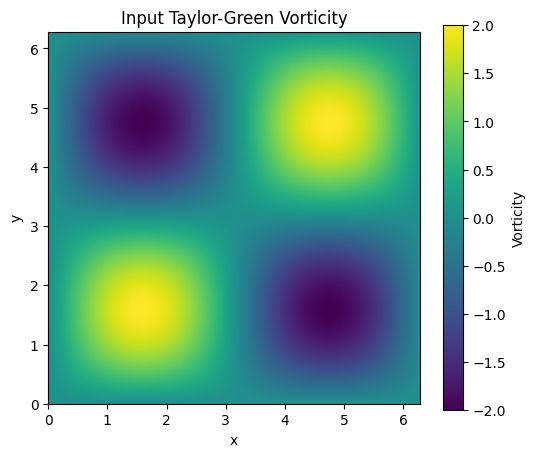

In [6]:
plt.figure(figsize=(6,5))

plt.imshow(
    omega.T,
    origin="lower",
    extent=[0,Lx,0,Ly],
    aspect="equal"
)

plt.colorbar(label="Vorticity")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Input Taylor-Green Vorticity")

plt.show()

In [7]:
# ============================================================
# SECTION 6 — CLASSICAL FFT VELOCITY SOLVER
# ============================================================

def velocity_from_vorticity_fft(omega, Lx, Ly):
    """
    Recover complex velocity U = u + i v from
    a 2D vorticity field using the Fourier-space
    velocity-Poisson equation.

    Equations:

        Delta u = - d(omega)/dy

        Delta v =   d(omega)/dx

    Therefore:

        u_hat =  i ky / (kx^2 + ky^2) * omega_hat

        v_hat = -i kx / (kx^2 + ky^2) * omega_hat

    and

        U_hat = (kx + i ky)/(kx^2 + ky^2) * omega_hat
    """

    Nx, Ny = omega.shape

    dx = Lx / Nx
    dy = Ly / Ny

    # Fourier wave numbers
    kx = 2*np.pi*np.fft.fftfreq(Nx, d=dx)
    ky = 2*np.pi*np.fft.fftfreq(Ny, d=dy)

    KX, KY = np.meshgrid(kx, ky, indexing="ij")

    K2 = KX**2 + KY**2

    # Fourier transform of vorticity
    omega_hat = np.fft.fft2(omega)

    # Avoid division by zero at k=(0,0)
    K2[0,0] = 1.0

    # Complex velocity filter
    velocity_filter = (KX + 1j*KY) / K2

    # Zero velocity mean / zero mode
    velocity_filter[0,0] = 0.0

    # Complex velocity in Fourier space
    U_hat = velocity_filter * omega_hat

    # Back to physical space
    U = np.fft.ifft2(U_hat)

    return U

In [8]:
# ============================================================
# SECTION 7 — CLASSICAL REFERENCE VELOCITY
# ============================================================

U_classical = velocity_from_vorticity_fft(
    omega,
    Lx,
    Ly
)

print("Classical velocity shape:", U_classical.shape)
print("dtype:", U_classical.dtype)

Classical velocity shape: (128, 128)
dtype: complex128


In [10]:
# ============================================================
# SECTION 8 — EXACT TGV VELOCITY FOR VALIDATION
# ============================================================

def tgv_velocity(X, Y, t=0.0, nu=0.01):

    decay = np.exp(-2.0 * nu * t)

    u = np.sin(X) * np.cos(Y) * decay
    v = -np.cos(X) * np.sin(Y) * decay

    return u, v

u_exact, v_exact = tgv_velocity(X, Y, t, nu)

U_exact = u_exact + 1j*v_exact

In [11]:
# ============================================================
# CLASSICAL FFT VALIDATION
# ============================================================

classical_error = (
    np.linalg.norm(U_classical - U_exact)
    /
    np.linalg.norm(U_exact)
)

print("Classical relative L2 error =", classical_error)

Classical relative L2 error = 4.0822917435203866e-16


In [13]:
# ============================================================
# SECTION 9 — QUANTUM SPECTRAL FILTER
# ============================================================

def velocity_spectral_filter(Nx, Ny, Lx, Ly):

    dx = Lx / Nx
    dy = Ly / Ny

    kx = 2*np.pi*np.fft.fftfreq(Nx, d=dx)
    ky = 2*np.pi*np.fft.fftfreq(Ny, d=dy)

    KX, KY = np.meshgrid(kx, ky, indexing="ij")

    K2 = KX**2 + KY**2

    K2[0,0] = 1.0

    G = (KX + 1j*KY) / K2

    # Remove zero mode
    G[0,0] = 0.0

    return G



G_velocity = velocity_spectral_filter(
    Nx,
    Ny,
    Lx,
    Ly
)

print("Filter shape:", G_velocity.shape)

Filter shape: (128, 128)


In [15]:
# ============================================================
# SECTION 10 — VECTORIZE VORTICITY
# ============================================================

omega_vector = omega.flatten()

print("Vector shape:", omega_vector.shape)
print("Number of amplitudes:", len(omega_vector))


# ============================================================
# SECTION 11 — QUANTUM INPUT STATE
# ============================================================

omega_norm = np.linalg.norm(omega_vector)

omega_state = omega_vector / omega_norm

print("Input norm:", np.linalg.norm(omega_state))

Vector shape: (16384,)
Number of amplitudes: 16384
Input norm: 1.0


In [20]:
# ============================================================
# SECTION 12 — BLOCK ENCODING NORMALIZATION
# ============================================================

G_flat = G_velocity.flatten()

alpha = np.max(np.abs(G_flat))

print("Block encoding alpha =", alpha)


G_normalized = G_flat / alpha

print(
    "Maximum normalized filter magnitude =",
    np.max(np.abs(G_normalized))
)

Block encoding alpha = 1.0
Maximum normalized filter magnitude = 1.0


In [21]:
# ============================================================
# SECTION 13 — QUANTUM FOURIER TRANSFORM
# ============================================================

def apply_qft_to_state(state, n_x, n_y):

    qc = QuantumCircuit(n_x + n_y)

    qft_x = QFT(n_x)
    qft_y = QFT(n_y)

    qc.append(qft_x, list(range(n_x)))
    qc.append(qft_y, list(range(n_x, n_x+n_y)))

    sv = Statevector(state)

    return sv.evolve(qc)